# TerGRASP: Ternary Singular Parameter Replacement for Redundant Layers

Complete Colab implementation for comparing:

- **Hard Layer Removal (ShortGPT-style)**
- **TerGRASP Hybrid Replacement**
- Perplexity on a small calibration set
- Angular-distance-based layer redundancy ranking

> **Note:** This notebook follows the supplied implementation. It disables KV caching during sequence evaluation and re-indexes retained layers after hard pruning.

In [1]:
# 1. Install Dependencies
!pip install -q transformers accelerate torch matplotlib numpy

import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import AutoModelForCausalLM, AutoTokenizer
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
model_name = "HuggingFaceTB/SmolLM-135M"

# You can also test with:
# model_name = "Qwen/Qwen2.5-0.5B"

print(f"Loading {model_name} on {device}...")

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16,
    device_map=device
)

model.config.use_cache = False


Loading HuggingFaceTB/SmolLM-135M on cpu...


config.json:   0%|          | 0.00/724 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/3.69k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/801k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/466k [00:00<?, ?B/s]

...

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors: reconstructing file:   0%|          |  0.00B /  538MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/111 [00:00<?, ?B/s]

In [2]:
# Calibration dataset for testing layer redundancy and perplexity calibration
calibration_texts = [
    "Large language models have revolutionized artificial intelligence and natural language processing.",
    "Layer pruning and low-bit quantization significantly reduce transformer computational complexity.",
    "Singular value decomposition allows low-rank approximation of redundant neural network parameters.",
    "BitNet b1.58 restricts weights to ternary values minus one, zero, and positive one."
]


In [3]:
# Perplexity evaluation

def eval_perplexity(eval_model, texts):
    """Evaluates perplexity on calibration text without KV caching."""
    eval_model.eval()
    eval_model.config.use_cache = False

    total_loss = 0.0
    total_tokens = 0

    with torch.no_grad():
        for t in texts:
            inputs = tokenizer(t, return_tensors="pt").to(device)

            outputs = eval_model(
                **inputs,
                labels=inputs["input_ids"],
                use_cache=False
            )

            num_tokens = inputs["input_ids"].numel()
            total_loss += outputs.loss.item() * num_tokens
            total_tokens += num_tokens

    return float(torch.exp(torch.tensor(total_loss / total_tokens)))


baseline_ppl = eval_perplexity(model, calibration_texts)
print(f"Baseline Model Perplexity: {baseline_ppl:.2f}")


Baseline Model Perplexity: 107.68


In [6]:
# 2. Compute Angular Distance Layer Redundancy Profile

# Add padding token to the tokenizer if it doesn't have one
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

sample_input = tokenizer(
    calibration_texts,
    return_tensors="pt",
    padding=True,
    truncation=True
).to(device)

with torch.no_grad():
    outputs = model(
        **sample_input,
        output_hidden_states=True,
        use_cache=False
    )

hidden_states = outputs.hidden_states

angular_distances = []

for i in range(len(hidden_states) - 1):
    h_in = hidden_states[i]
    h_out = hidden_states[i + 1]

    cos_sim = F.cosine_similarity(
        h_in,
        h_out,
        dim=-1
    ).mean().item()

    angular_distances.append((i, 1.0 - cos_sim))

# Sort by smallest distance = most redundant layer first
sorted_redundant = sorted(
    angular_distances,
    key=lambda x: x[1]
)

print("\nLayer Redundancy Ranking (Index, Angular Distance):")

for idx, dist in sorted_redundant[:5]:
    print(f" Layer {idx:2d}: Angular Distance = {dist:.4f}")


Layer Redundancy Ranking (Index, Angular Distance):
 Layer 16: Angular Distance = 0.0107
 Layer 27: Angular Distance = 0.0112
 Layer 15: Angular Distance = 0.0117
 Layer 17: Angular Distance = 0.0122
 Layer 14: Angular Distance = 0.0146


In [7]:
# 3. Define TerGRASP PyTorch Module
# 1.58-Bit Ternary SVD Bridge

class TerGRASP_BridgeModule(nn.Module):
    def __init__(self, hidden_dim, rank=32, scale=0.1):
        super().__init__()

        self.rank = rank
        self.scale = scale

        # Initialize low-rank singular vectors
        self.U = nn.Parameter(
            torch.randn(
                hidden_dim,
                rank,
                dtype=torch.float16
            ) * 0.02
        )

        self.Vt = nn.Parameter(
            torch.randn(
                rank,
                hidden_dim,
                dtype=torch.float16
            ) * 0.02
        )

    def quantize_ternary(self, W):
        """AbsMean ternary quantization to {-1, 0, +1}."""

        gamma = torch.mean(torch.abs(W)) + 1e-8
        W_scaled = W / gamma
        W_quant = torch.round(W_scaled).clamp(-1, 1)

        return W_quant * gamma

    def forward(self, hidden_states, *args, **kwargs):
        x = (
            hidden_states[0]
            if isinstance(hidden_states, tuple)
            else hidden_states
        )

        U_q = self.quantize_ternary(self.U)
        Vt_q = self.quantize_ternary(self.Vt)

        proj = torch.matmul(x, U_q)
        delta = torch.matmul(proj, Vt_q)

        out = x + self.scale * delta

        # HuggingFace Transformer layers expect tuple return format
        return (out,)


In [9]:
# 4. Benchmark Loop
# Hard Layer Removal vs TerGRASP Hybrid

# Monkey-patch TerGRASP_BridgeModule.forward to return a tensor directly
# The original definition in cell 920f606f returns (out,),
# which causes an AttributeError when passed to subsequent layers.
def _tergrasp_bridge_module_fixed_forward(self, hidden_states, *args, **kwargs):
    x = (
        hidden_states[0]
        if isinstance(hidden_states, tuple)
        else hidden_states
    )

    U_q = self.quantize_ternary(self.U)
    Vt_q = self.quantize_ternary(self.Vt)

    proj = torch.matmul(x, U_q)
    delta = torch.matmul(proj, Vt_q)

    out = x + self.scale * delta

    # Fix: Return tensor directly, not a tuple
    return out

TerGRASP_BridgeModule.forward = _tergrasp_bridge_module_fixed_forward

def run_compression_benchmark(
    model_name,
    k_list=[1, 2, 3, 4]
):
    results = {
        "hard_pruning": [],
        "tergrasp_hybrid": []
    }

    for k in k_list:
        target_layers = [
            idx for idx, _ in sorted_redundant[:k]
        ]

        print(
            f"\n--- Testing Compression for "
            f"k={k} layers ({target_layers}) ---"
        )

        # ---------------------------------------------------------
        # A. Hard Layer Removal
        # ---------------------------------------------------------
        m_hard = AutoModelForCausalLM.from_pretrained(
            model_name,
            torch_dtype=torch.float16,
            device_map=device
        )

        m_hard.config.use_cache = False

        m_hard.model.layers = nn.ModuleList([
            layer
            for i, layer in enumerate(m_hard.model.layers)
            if i not in target_layers
        ])

        m_hard.config.num_hidden_layers = len(
            m_hard.model.layers
        )

        # Re-index remaining layers so internal KV-cache indexing
        # remains consistent if caching is enabled later.
        for i, layer in enumerate(m_hard.model.layers):
            if hasattr(layer, "layer_idx"):
                layer.layer_idx = i

        ppl_hard = eval_perplexity(
            m_hard,
            calibration_texts
        )

        results["hard_pruning"].append(ppl_hard)

        print(
            f" Hard Layer Removal Perplexity: "
            f"{ppl_hard:.2f}"
        )

        del m_hard
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        # ---------------------------------------------------------
        # B. TerGRASP Hybrid Replacement
        # ---------------------------------------------------------
        m_tergrasp = AutoModelForCausalLM.from_pretrained(
            model_name,
            torch_dtype=torch.float16,
            device_map=device
        )

        m_tergrasp.config.use_cache = False

        hidden_dim = m_tergrasp.config.hidden_size

        for idx in target_layers:
            m_tergrasp.model.layers[idx] = (
                TerGRASP_BridgeModule(
                    hidden_dim=hidden_dim,
                    rank=32
                ).to(device)
            )

        ppl_tg = eval_perplexity(
            m_tergrasp,
            calibration_texts
        )

        results["tergrasp_hybrid"].append(ppl_tg)

        print(
            f" TerGRASP Hybrid Perplexity: "
            f"{ppl_tg:.2f}"
        )

        del m_tergrasp
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    return k_list, results


# Run sweep across k=1 to k=4 layers
k_list, results = run_compression_benchmark(
    model_name,
    k_list=[1, 2, 3, 4]
)



--- Testing Compression for k=1 layers ([16]) ---


Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

 Hard Layer Removal Perplexity: 106.81


Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

 TerGRASP Hybrid Perplexity: 105.43

--- Testing Compression for k=2 layers ([16, 27]) ---


...

 TerGRASP Hybrid Perplexity: 173.63

--- Testing Compression for k=4 layers ([16, 27, 15, 17]) ---


Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

 Hard Layer Removal Perplexity: 178.02


Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

 TerGRASP Hybrid Perplexity: 177.08


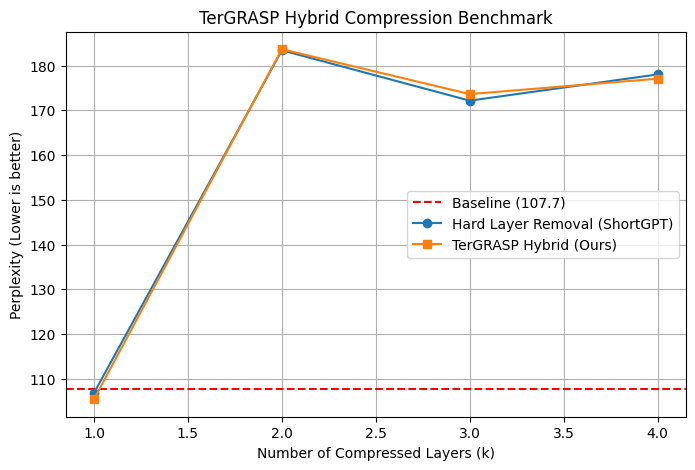

In [10]:
# 5. Plot Comparison Results

plt.figure(figsize=(8, 5))

plt.axhline(
    y=baseline_ppl,
    color="r",
    linestyle="--",
    label=f"Baseline ({baseline_ppl:.1f})"
)

plt.plot(
    k_list,
    results["hard_pruning"],
    marker="o",
    label="Hard Layer Removal (ShortGPT)"
)

plt.plot(
    k_list,
    results["tergrasp_hybrid"],
    marker="s",
    label="TerGRASP Hybrid (Ours)"
)

plt.xlabel("Number of Compressed Layers (k)")
plt.ylabel("Perplexity (Lower is better)")
plt.title("TerGRASP Hybrid Compression Benchmark")
plt.grid(True)
plt.legend()
plt.show()
